In [1]:
import h5py
from deltaf import findBaselineF0

import scipy.io as sio
import autograd.numpy as np
import autograd.numpy.random as npr
npr.seed(12345)
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

from statsmodels.tsa.api import SimpleExpSmoothing

In [2]:
# controller

In [3]:
def get_trial_data(mouse, activity):
    if activity == "eat3":
            filepath = f'data/{mouse}_eat3.h5'
            with h5py.File(filepath, 'r') as f:
                trial_data = np.einsum('nti -> itn', f[mouse]['eat3'][:])
    elif mouse in ["M1", "M2"]:
        filepath = 'data/Refined_eat_drink_social_forNK.mat'
        raw = sio.loadmat(filepath)
        trial_data = np.einsum('nti -> itn', raw[f"{mouse}_{activity}"])
    else:
        filepath = 'data/june1_processed_data_no_social.h5'
        with h5py.File(filepath, 'r') as f:
            trial_data = np.einsum('nti -> itn', f[mouse][activity][:])
    return trial_data

In [4]:
def plot_trial_data(trial_data, idx, title):


    fig, ax = plt.subplots()

    im = ax.imshow(
        trial_data[idx].T,
        aspect='auto',
        extent=[0, 401, trial_data.shape[2], 1],
        interpolation='none',
        cmap='magma'
    )

    ax.set_xticks([0, 100, 200, 300, 400])
    ax.set_xlabel('frames',)     # set xlabel font size
    ax.set_ylabel('neuron',)      # set ylabel font size
    ax.set_title(title)  # set title font size

    ax.tick_params(axis='both', which='major',)  # set tick label size

    # fig.colorbar(im, ax=ax)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('ΔF/F', rotation=90)
    plt.tight_layout()

In [5]:
def normalise_data(data):
    data = (data - data.mean(0)) / data.std(0)
    return data

def baseline_subtract_data(data, Fs=10):
    baseline = findBaselineF0(data, Fs, axis=1, keepdims=True)
    baseline_subtract_data = data - baseline
    return baseline_subtract_data

In [6]:
def smooth_data(data, tau=0.1):
    smoothing_level = 1 / tau

    smoothed_data = []
    for trial in data:

        smooth_trial = []
        for neuron in trial.T:
            fit = SimpleExpSmoothing(neuron, initialization_method="heuristic").fit(smoothing_level=smoothing_level, optimized=False)
            smooth_trial.append(fit.fittedvalues)
        smooth_trial = np.array(smooth_trial)
        smoothed_data.append(smooth_trial.T)
    data = np.array(smoothed_data)
    return data

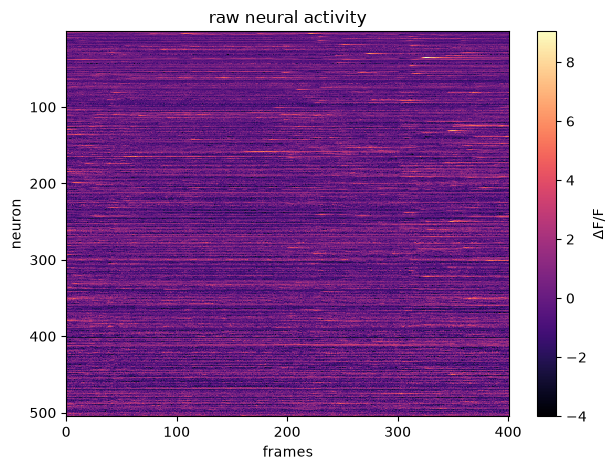

In [7]:
M2_eat3_data = get_trial_data("M2", "eat3")
plot_trial_data(M2_eat3_data, 0, "raw neural activity")

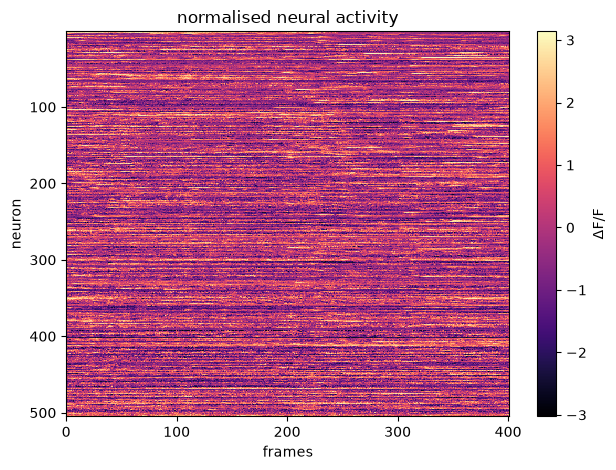

In [8]:
normalised_M2_eat3_data = normalise_data(M2_eat3_data)
plot_trial_data(normalised_M2_eat3_data, 0, "normalised neural activity")

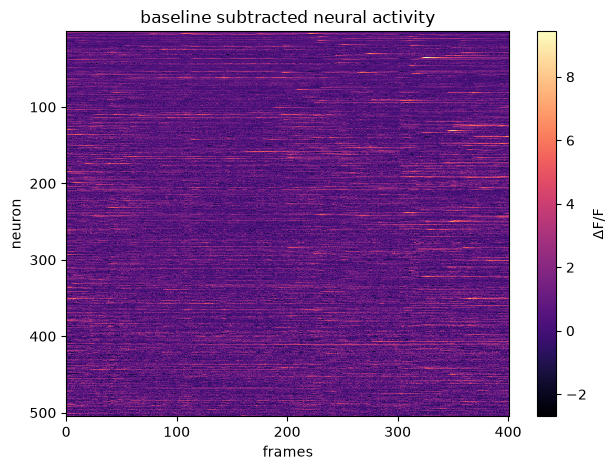

In [9]:
baseline_subtracted_M2_eat3_data = baseline_subtract_data(M2_eat3_data)
plot_trial_data(baseline_subtracted_M2_eat3_data, 0, "baseline subtracted neural activity")

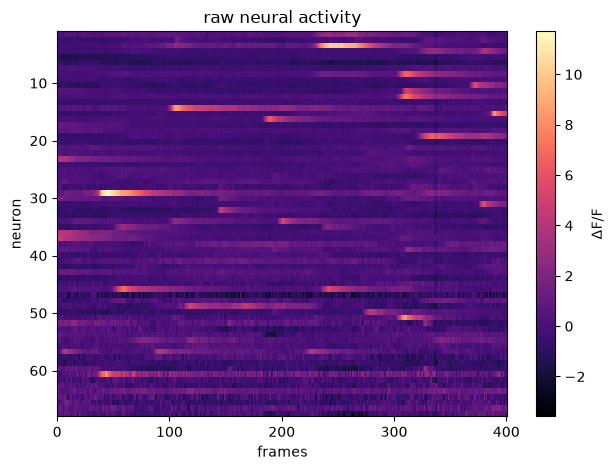

In [10]:
g12_eat_data = get_trial_data("g12", "eat")
plot_trial_data(g12_eat_data, 0, "raw neural activity")

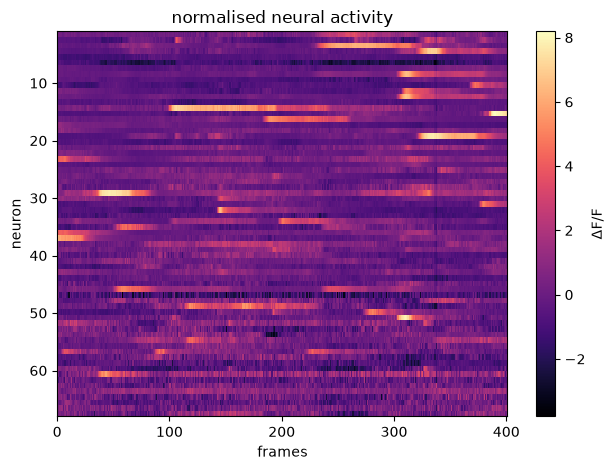

In [11]:
normalised_g12_eat_data = normalise_data(g12_eat_data)
plot_trial_data(normalised_g12_eat_data, 0, "normalised neural activity")

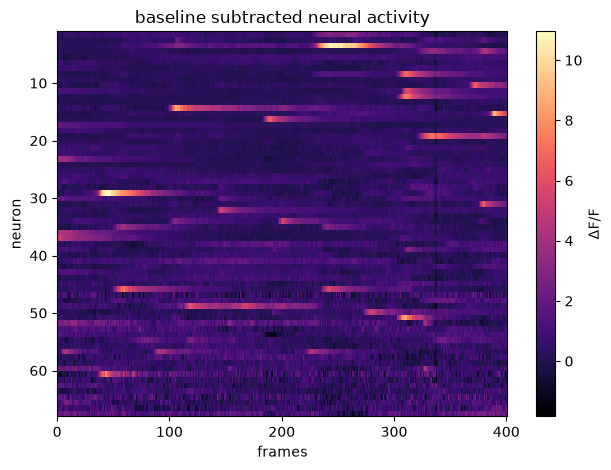

In [12]:
baseline_subtracted_g12_eat_data = baseline_subtract_data(g12_eat_data)
plot_trial_data(baseline_subtracted_g12_eat_data, 0, "baseline subtracted neural activity")

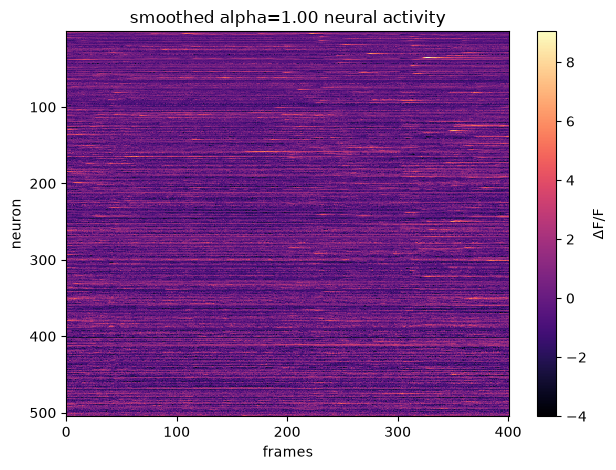

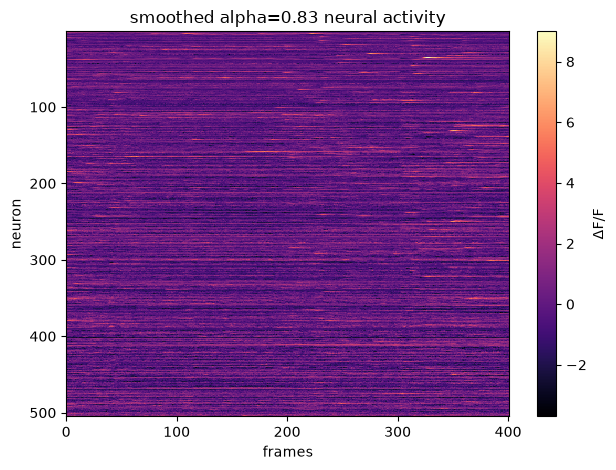

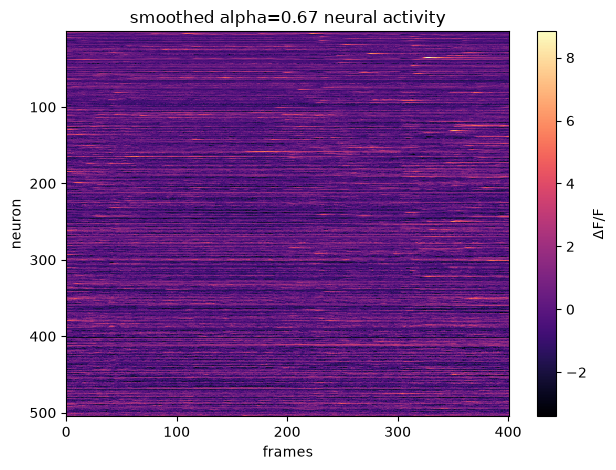

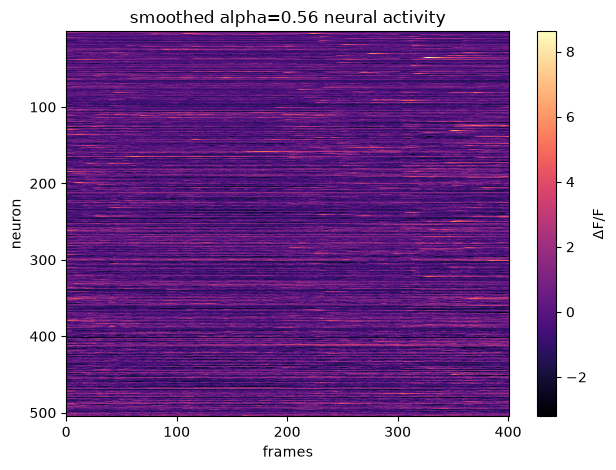

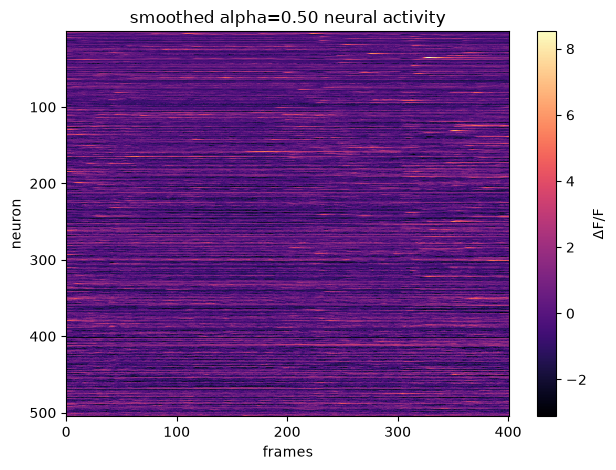

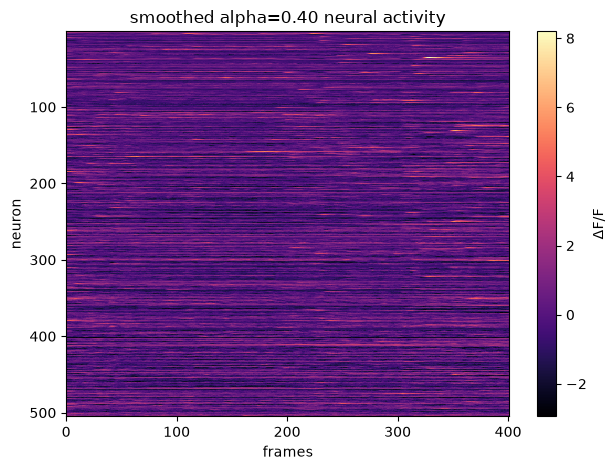

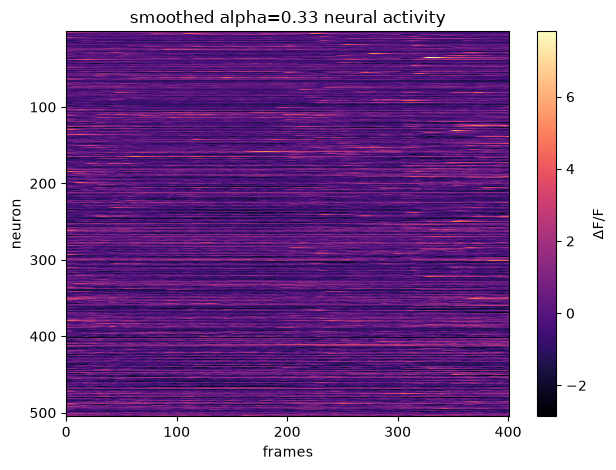

In [13]:
tau_list = [1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0]

for tau in tau_list:
    smoothed_M2_eat3_data = smooth_data(M2_eat3_data, tau=tau)
    alpha = 1 / tau
    plot_trial_data(smoothed_M2_eat3_data, 0, f"smoothed alpha={alpha:.2f} neural activity")
    plt.show()
    plt.close("all")

In [14]:
# tau_list = [1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0]

# for tau in tau_list:
#     smoothed_g12_eat_data = smooth_data(g12_eat_data, tau=tau)
#     plot_trial_data(smoothed_g12_eat_data, 0, f"smoothed tau={tau} neural activity")
#     plt.show()
#     plt.close("all")

In [15]:
def train_pca(data, n_components=10):
    pca = PCA(n_components=n_components)
    pca.fit(data.reshape(-1, data.shape[2]))
    return pca

def apply_pca(data, pca):
    transformed_data = pca.transform(data.reshape(-1, data.shape[2]))
    transformed_data = transformed_data.reshape(data.shape[0], data.shape[1], -1)
    return transformed_data

In [16]:
n_components = 25

In [17]:
M2_eat_data = get_trial_data("M2", "eat")
M2_eat3_data = get_trial_data("M2", "eat3")
baseline_subtracted_M2_eat_data = baseline_subtract_data(M2_eat_data)
baseline_subtracted_M2_eat3_data = baseline_subtract_data(M2_eat3_data)

M2_eat_pca_model = train_pca(baseline_subtracted_M2_eat_data, n_components=n_components)
M2_eat3_transformed_data = apply_pca(baseline_subtracted_M2_eat3_data, M2_eat_pca_model)

In [18]:
M2_eat3_transformed_data.shape

(11, 401, 25)

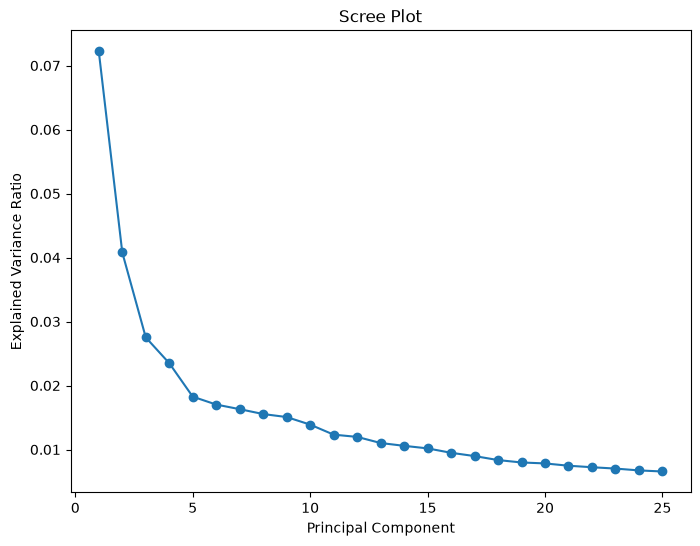

In [19]:
# skree plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(M2_eat_pca_model.explained_variance_ratio_) + 1), M2_eat_pca_model.explained_variance_ratio_, 'o-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

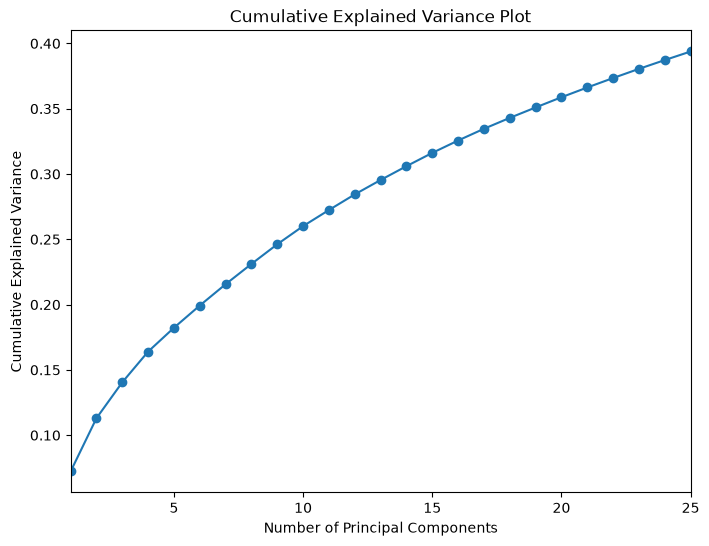

In [20]:
# cumulative variance plot
cumulative_variance = np.cumsum(M2_eat_pca_model.explained_variance_ratio_)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance Plot')
plt.xlim(1, n_components)
plt.show()

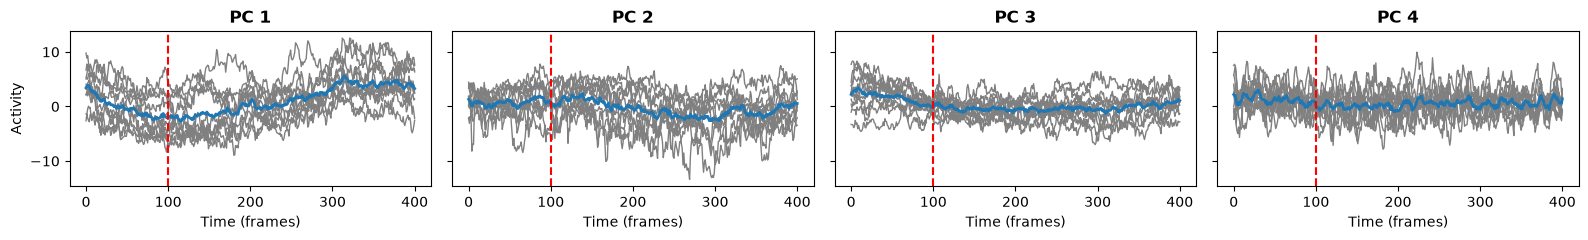

In [21]:
pca_to_display = 4

fig, axes = plt.subplots(1, pca_to_display, figsize=(4*pca_to_display, 2.5), sharex=True, sharey=True)
for i in range(pca_to_display):
    # Plot all trials in grey
    for j in range(M2_eat3_transformed_data.shape[0]):
        axes[i].plot(M2_eat3_transformed_data[j, :, i], lw=1, c='grey', zorder=1)
    # Plot mean in blue
    mean_data = M2_eat3_transformed_data[:, :, i].mean(axis=0)
    axes[i].plot(mean_data, lw=2, zorder=2)
    axes[i].axvline(x=100, color='r', linestyle='--')
    axes[i].set_title(f'PC {i+1}', fontweight='bold')
    axes[i].set_xlabel('Time (frames)')
    if i == 0:
        axes[i].set_ylabel('Activity')

plt.tight_layout()

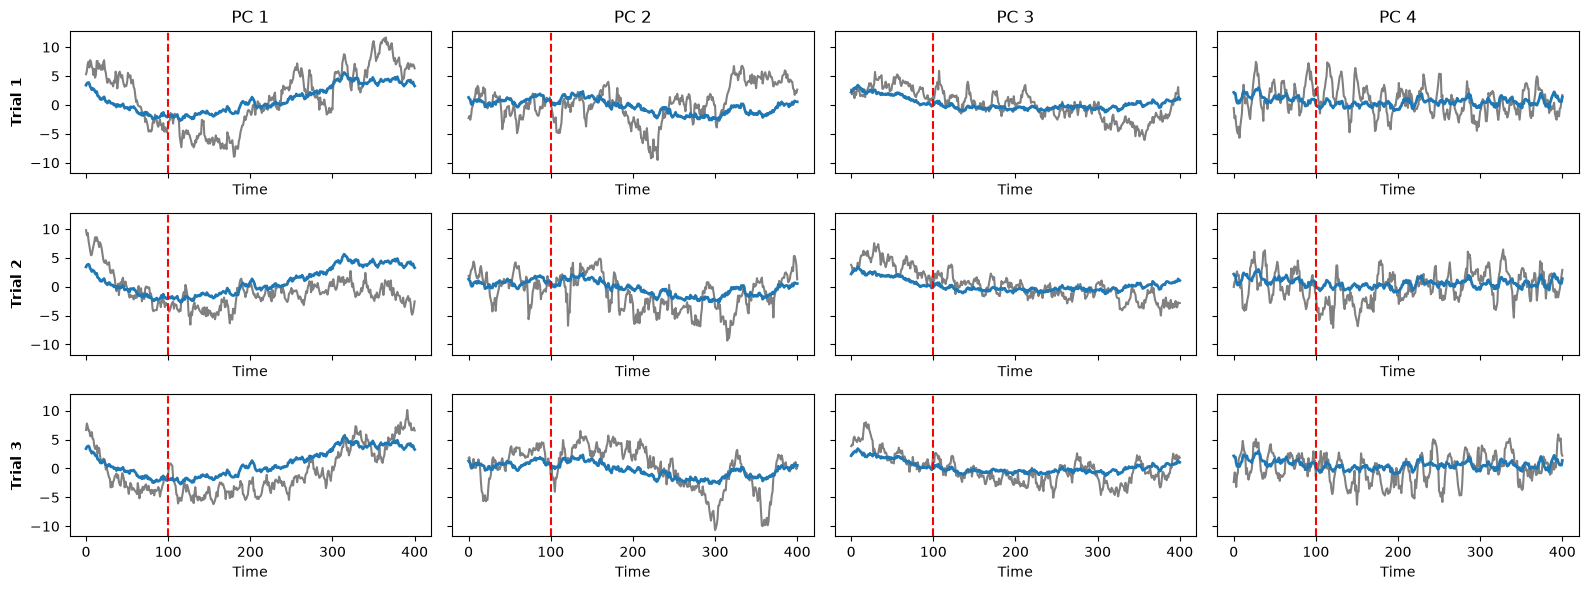

In [22]:
pca_to_display = 4
trials_to_display = 3

fig, axes = plt.subplots(trials_to_display, min(M2_eat3_transformed_data.shape[2], pca_to_display),
                          figsize=(4*min(M2_eat3_transformed_data.shape[2], pca_to_display), 2*trials_to_display),
                          sharex=True, sharey=True)
for i in range(trials_to_display):  # for each trial
    for j in range(min(M2_eat3_transformed_data.shape[2], pca_to_display)):  # for each component
        axes[i, j].plot(M2_eat3_transformed_data[i, :, j], lw=1.5, c='grey')
        # Plot mean
        mean_data = M2_eat3_transformed_data[:, :, j].mean(axis=0)
        axes[i, j].plot(mean_data, lw=2)
        axes[i, j].axvline(x=100, color='r', linestyle='--')
        if j == 0:
            axes[i, j].set_ylabel(f'Trial {i+1}', fontweight='bold')
        if i == 0:
            axes[i, j].set_title(f'PC {j+1}')
        axes[i, j].set_xlabel('Time')

plt.tight_layout()

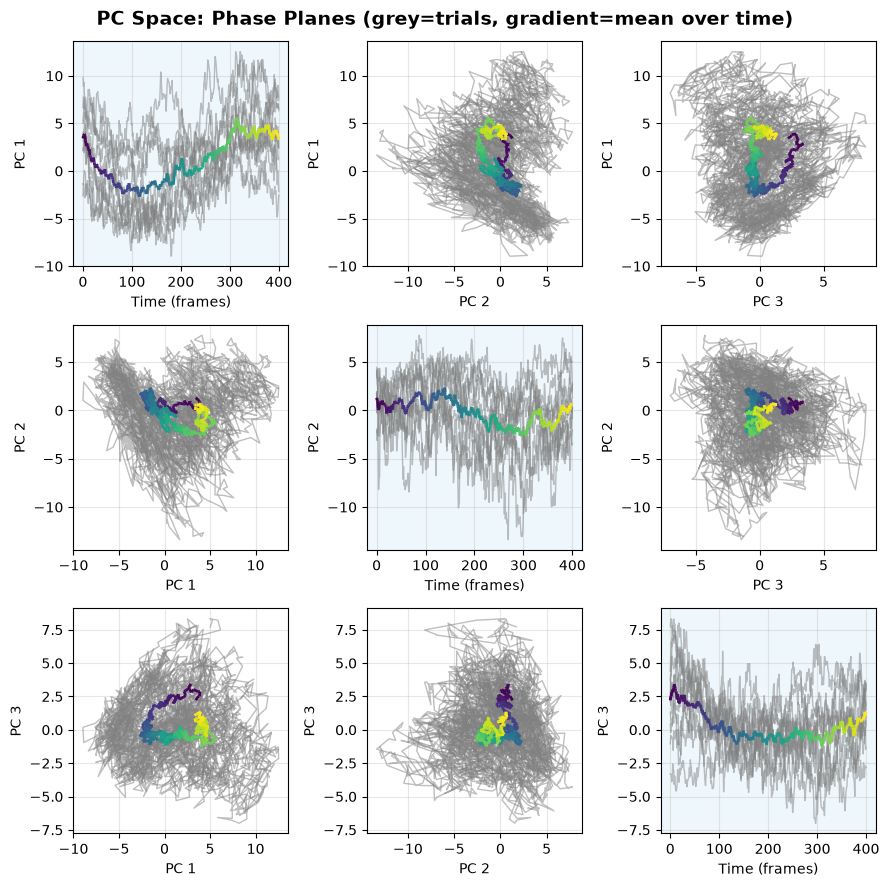

In [23]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import numpy as np

n_components_to_plot = 3
fig, axes = plt.subplots(n_components_to_plot, n_components_to_plot, 
                          figsize=(3*n_components_to_plot, 3*n_components_to_plot))

norm = Normalize(vmin=0, vmax=M2_eat3_transformed_data.shape[1]-1)
cmap = plt.cm.viridis

for i in range(n_components_to_plot):
    for j in range(n_components_to_plot):
        if i == j:
            axes[i, j].set_facecolor('#eef7fb')
            # Diagonal: plot individual traces
            for trial in range(M2_eat3_transformed_data.shape[0]):
                axes[i, j].plot(M2_eat3_transformed_data[trial, :, i], lw=1, c='grey', alpha=0.5)
            
            # Mean trace with time gradient
            mean_trace = M2_eat3_transformed_data[:, :, i].mean(axis=0)
            time_points = np.arange(len(mean_trace))
            
            points = np.array([time_points, mean_trace]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2)
            lc.set_array(np.arange(len(mean_trace)-1))
            axes[i, j].add_collection(lc)
            axes[i, j].autoscale()
            
        else:
            # Off-diagonal: plot phase planes
            for trial in range(M2_eat3_transformed_data.shape[0]):
                axes[i, j].plot(M2_eat3_transformed_data[trial, :, j], 
                               M2_eat3_transformed_data[trial, :, i], 
                               lw=1, c='grey', alpha=0.5)
            
            # Plot mean trajectory with time gradient
            mean_x = M2_eat3_transformed_data[:, :, j].mean(axis=0)
            mean_y = M2_eat3_transformed_data[:, :, i].mean(axis=0)
            
            points = np.array([mean_x, mean_y]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2)
            lc.set_array(np.arange(len(mean_x)-1))
            axes[i, j].add_collection(lc)
            axes[i, j].autoscale()
            
        axes[i, j].set_ylabel(f'PC {i+1}')
        
        if i == j:
            axes[i, j].set_xlabel('Time (frames)')
        else:
            axes[i, j].set_xlabel(f'PC {j+1}')
        
        axes[i, j].grid(True, alpha=0.3)

plt.suptitle('PC Space: Phase Planes (grey=trials, gradient=mean over time)', fontsize=14, fontweight='bold')
plt.tight_layout()


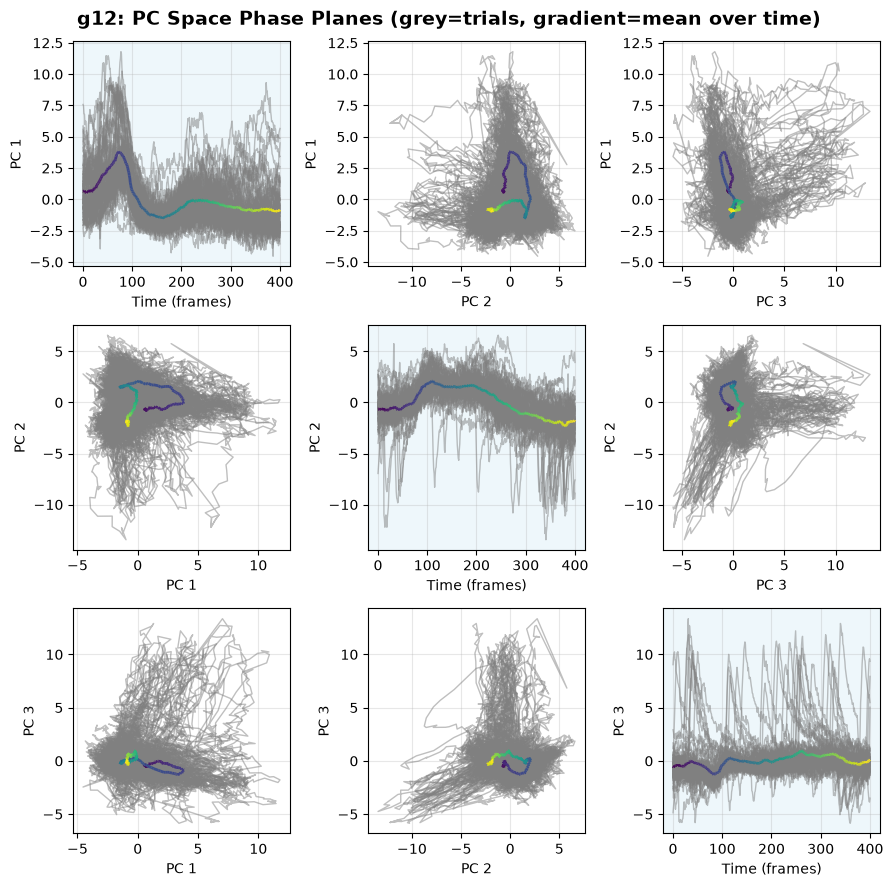

In [24]:
# g12 version of the same phase-plane figure, kept separate from the existing M2 plot

g12_eat_data = get_trial_data("g12", "eat")
baseline_subtracted_g12_eat_data = baseline_subtract_data(g12_eat_data)

g12_eat_pca_model = train_pca(baseline_subtracted_g12_eat_data, n_components=n_components)
g12_eat_transformed_data = apply_pca(baseline_subtracted_g12_eat_data, g12_eat_pca_model)

n_components_to_plot = 3
fig, axes = plt.subplots(n_components_to_plot, n_components_to_plot,
                          figsize=(3*n_components_to_plot, 3*n_components_to_plot))

norm = Normalize(vmin=0, vmax=g12_eat_transformed_data.shape[1]-1)
cmap = plt.cm.viridis

for i in range(n_components_to_plot):
    for j in range(n_components_to_plot):
        if i == j:
            axes[i, j].set_facecolor('#eef7fb')
            for trial in range(g12_eat_transformed_data.shape[0]):
                axes[i, j].plot(g12_eat_transformed_data[trial, :, i], lw=1, c='grey', alpha=0.5)

            mean_trace = g12_eat_transformed_data[:, :, i].mean(axis=0)
            time_points = np.arange(len(mean_trace))
            points = np.array([time_points, mean_trace]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2)
            lc.set_array(np.arange(len(mean_trace)-1))
            axes[i, j].add_collection(lc)
            axes[i, j].autoscale()

        else:
            for trial in range(g12_eat_transformed_data.shape[0]):
                axes[i, j].plot(g12_eat_transformed_data[trial, :, j],
                               g12_eat_transformed_data[trial, :, i],
                               lw=1, c='grey', alpha=0.5)

            mean_x = g12_eat_transformed_data[:, :, j].mean(axis=0)
            mean_y = g12_eat_transformed_data[:, :, i].mean(axis=0)
            points = np.array([mean_x, mean_y]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2)
            lc.set_array(np.arange(len(mean_x)-1))
            axes[i, j].add_collection(lc)
            axes[i, j].autoscale()

        axes[i, j].set_ylabel(f'PC {i+1}')

        if i == j:
            axes[i, j].set_xlabel('Time (frames)')
        else:
            axes[i, j].set_xlabel(f'PC {j+1}')

        axes[i, j].grid(True, alpha=0.3)

plt.suptitle('g12: PC Space Phase Planes (grey=trials, gradient=mean over time)', fontsize=14, fontweight='bold')
plt.tight_layout()